In [1]:
!pip install tensorflow

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import kagglehub

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam

# config
SEQ_LEN = 7200
HORIZON = 60
STEP = 20
LSR_MODEL_PATH = "LSR_Residual_Model.keras"
PURE_MODEL_PATH = "Pure_LSTM_Model.keras"

In [3]:
path = kagglehub.dataset_download("rockinbrock/spy-1-minute-data")
files = os.listdir(path)
csv_file = [f for f in files if f.lower().endswith(".csv")][0]
df = pd.read_csv(os.path.join(path, csv_file))

# last 100k rows for ram, sort by date
df = df.tail(100_000).reset_index(drop=True)
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

# split
df_train = df.tail(50_000).reset_index(drop=True)
features = ['open','high','low','close','volume','barCount','average']

print(f"Training Data Shape: {df_train.shape}")

Using Colab cache for faster access to the 'spy-1-minute-data' dataset.
Training Data Shape: (50000, 8)


In [4]:
#original
import torch
import torch.nn as nn
from torch.autograd import Variable
import torch.nn.functional as F
import torch.nn.init as init


class SRU(nn.Module):
    def __init__(self, input_size, phi_size, r_size, cell_out_size, output_size, A=[0, 0.5, 0.9, 0.99, 0.999], dropout=0, gpu=True):
        """
        input_size:    inputの特徴量数
        phi_size:      phiのユニット数。\mu^{\alpha}の次元とも等しい
        r_size:        rのユニット数
        cell_out_size: SRUCellからの出力のunit数
        output_size:   outputの次元
        A:             [\alpha_1, \alpha_2, ..., \alpha_m]
        """

        super(SRU, self).__init__()

        self._gpu = gpu
        self.n_alpha  = len(A)
        self.phi_size = phi_size
        self.mu_size  = self.phi_size * self.n_alpha # muのユニット数 = phiのユニット数 * alphaの個数

        # 各結合の定義
        self.mu2r   = nn.Linear(self.mu_size, r_size)
        self.xr2phi = nn.Linear(input_size + r_size, phi_size)
        self.mu2o   = nn.Linear(self.mu_size, cell_out_size)
        self.drop   = nn.Dropout(p=dropout)
        self.linear = nn.Linear(cell_out_size, output_size)

        # muphi2phiの準備
        # A_mask: Kronecker product of (A, ones(1, phi_size)),  shape => (1, mu_dim)
        self.A_mask = torch.Tensor([x for x in(A) for i in range(phi_size)]).view(1, -1)
        if self._gpu == True:
            self.A_mask = self.A_mask.cuda()
        # A_maskは定数項なのでrequires_grad=Falseをつける
        self.A_mask = Variable(self.A_mask, requires_grad=False)

    def forward(self, x): # Changed 'inputs' to 'x' and removed the loop
        '''
        x.size()  => (sample_size, x_dim) # Updated docstring to reflect current input
        mu.size() => (sample_size, mu_dim)
        '''
        r = F.relu(self.mu2r(self.mu))
        phi = F.relu(self.xr2phi(torch.cat((x, r), 1)))
        self.mu = self.muphi2mu(self.mu, phi)
        cell_out = F.relu(self.mu2o(self.mu))
        cell_out = self.drop(cell_out)
        outputs  = self.linear(cell_out)
        return outputs

    def muphi2mu(self, mu, phi):
        '''
        数式: \mu = A_mask * \mu + (1-A_mask) * phi_tile
            A_mask:   Kronecker product of (A, ones(1, phi_size)),  shape => (1, mu_dim)
            phi_tile: Kronecker product of (ones(1, n_alpha), phi), shape => (sample_size, mu_dim)
        '''
        phi_tile = phi.repeat(1, self.n_alpha)
        mu = torch.mul(self.A_mask, mu) + torch.mul((1-self.A_mask), phi_tile)
        return mu

    def initWeight(self):
        for name, params in self.named_parameters():
            # weightをxavierで初期化
            if 'weight' in name:
                init.xavier_uniform(params, init.calculate_gain('relu'))
            # biasを0で初期化
            else:
                init.constant(params, 0)

    def initHidden(self, batch_size):
        self.mu = Variable(torch.zeros(batch_size, self.mu_size))
        if self._gpu == True:
            self.mu = self.mu.cuda()

<>:13: SyntaxWarning: invalid escape sequence '\m'
<>:57: SyntaxWarning: invalid escape sequence '\m'
<>:13: SyntaxWarning: invalid escape sequence '\m'
<>:57: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipython-input-2000751825.py:13: SyntaxWarning: invalid escape sequence '\m'
  phi_size:      phiのユニット数。\mu^{\alpha}の次元とも等しい
/tmp/ipython-input-2000751825.py:57: SyntaxWarning: invalid escape sequence '\m'
  数式: \mu = A_mask * \mu + (1-A_mask) * phi_tile


In [5]:
from torch.optim import Adam


class SRUBlock(nn.Module):
    """
    Wraps the provided SRU cell to behave like Keras:
    - return_sequences=True: output all time steps
    - return_sequences=False: output only final output
    """
    def __init__(self, sru_cell, return_sequences=True):
        super().__init__()
        self.sru_cell = sru_cell
        self.return_sequences = return_sequences

    def forward(self, x):
        """
        x: (batch, seq_len, input_dim)
        """
        batch, seq_len, _ = x.shape

        # initialize SRU hidden state
        self.sru_cell.initHidden(batch)

        outputs = []
        for t in range(seq_len):
            out_t = self.sru_cell(x[:, t, :])
            outputs.append(out_t)

        outputs = torch.stack(outputs, dim=1)   # (batch, seq_len, cell_out)

        if self.return_sequences:
            return outputs
        else:
            return outputs[:, -1, :]

In [6]:
class SRUForecastModel(nn.Module):
    def __init__(self, horizon):
        super().__init__()

        # SRU cell 1 (replace 1st LSTM)
        self.sru1 = SRU(
            input_size=7,
            phi_size=64,
            r_size=64,
            cell_out_size=64,
            output_size=64
        )
        self.sru_block1 = SRUBlock(self.sru1, return_sequences=True)

        self.dropout = nn.Dropout(0.2)

        # SRU cell 2 (replace 2nd LSTM)
        self.sru2 = SRU(
            input_size=64,
            phi_size=64,
            r_size=64,
            cell_out_size=64,
            output_size=64
        )
        self.sru_block2 = SRUBlock(self.sru2, return_sequences=False)

        self.fc1 = nn.Linear(64, 128)
        self.fc2 = nn.Linear(128, horizon)

    def forward(self, x):
        x = self.sru_block1(x)
        x = self.dropout(x)
        x = self.sru_block2(x)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [7]:
y_train_raw = df_train['close'].values
N_train = len(df_train)
t_train = np.arange(N_train)

#linear
trend_model = LinearRegression().fit(t_train.reshape(-1, 1), y_train_raw)
L_train = trend_model.predict(t_train.reshape(-1, 1))

#fourier
T_period = 1440
K = 5
seasonal_basis = []
for k in range(1, K+1):
    seasonal_basis.append(np.sin(2*np.pi*k*t_train/T_period))
    seasonal_basis.append(np.cos(2*np.pi*k*t_train/T_period))
seasonal_basis = np.vstack(seasonal_basis).T

seasonal_model = LinearRegression().fit(seasonal_basis, y_train_raw - L_train)
S_train = seasonal_model.predict(seasonal_basis)

R_train_raw = y_train_raw - L_train - S_train

#lstm on residuals
X_all = df_train[features].values.astype(np.float32)
X_lsr, y_lsr = [], []

for i in range(0, N_train - SEQ_LEN - HORIZON, STEP):
    X_lsr.append(X_all[i:i+SEQ_LEN])
    y_lsr.append(R_train_raw[i+SEQ_LEN:i+SEQ_LEN+HORIZON])

X_lsr = np.array(X_lsr, dtype=np.float32)
y_lsr = np.array(y_lsr, dtype=np.float32)


In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_lsr = SRUForecastModel(HORIZON).to(device)

optimizer = Adam(model_lsr.parameters(), lr=1e-3)
criterion = nn.MSELoss()

X_tensor = torch.tensor(X_lsr, dtype=torch.float32).to(device)
y_tensor = torch.tensor(y_lsr, dtype=torch.float32).to(device)

dataset = torch.utils.data.TensorDataset(X_tensor, y_tensor)
loader = torch.utils.data.DataLoader(dataset, batch_size=32, shuffle=True)

# Adjust SRU's gpu flag based on detected device
# This is important for initHidden to put mu on the correct device
model_lsr.sru1._gpu = (device.type == 'cuda')
model_lsr.sru2._gpu = (device.type == 'cuda')

PRINT_EVERY = 1   # print loss every N batches

EPOCHS = 2
for epoch in range(EPOCHS):
    model_lsr.train()
    total_loss = 0
    running_loss = 0.0

    for batch_idx, (xb, yb) in enumerate(loader):
        xb = xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad()
        preds = model_lsr(xb)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

        running_loss += loss.item()

        # Print progress mid-epoch
        if (batch_idx + 1) % PRINT_EVERY == 0:
            avg_loss = running_loss / PRINT_EVERY
            print(f"[Epoch {epoch+1}/{EPOCHS}] "
                  f"Batch {batch_idx+1}/{len(loader)} — "
                  f"Avg Loss: {avg_loss:.6f}")
            running_loss = 0.0

    print(f"Epoch {epoch+1}/{EPOCHS} — Loss: {total_loss:.4f}")

torch.save(model_lsr.state_dict(), LSR_MODEL_PATH)
print("L+S+R Model Trained.")

[Epoch 1/2] Batch 1/67 — Avg Loss: 42.891708
[Epoch 1/2] Batch 2/67 — Avg Loss: 49.313152
[Epoch 1/2] Batch 3/67 — Avg Loss: 53.923767
[Epoch 1/2] Batch 4/67 — Avg Loss: 32.863228
[Epoch 1/2] Batch 5/67 — Avg Loss: 36.660542
[Epoch 1/2] Batch 6/67 — Avg Loss: 28.625998
[Epoch 1/2] Batch 7/67 — Avg Loss: 33.216553
[Epoch 1/2] Batch 8/67 — Avg Loss: 54.212688
[Epoch 1/2] Batch 9/67 — Avg Loss: 35.610100
[Epoch 1/2] Batch 10/67 — Avg Loss: 38.930256
[Epoch 1/2] Batch 11/67 — Avg Loss: 32.193192
[Epoch 1/2] Batch 12/67 — Avg Loss: 32.092167
[Epoch 1/2] Batch 13/67 — Avg Loss: 27.080553
[Epoch 1/2] Batch 14/67 — Avg Loss: 18.915508
[Epoch 1/2] Batch 15/67 — Avg Loss: 36.181641
[Epoch 1/2] Batch 16/67 — Avg Loss: 23.501047
[Epoch 1/2] Batch 17/67 — Avg Loss: 28.648764
[Epoch 1/2] Batch 18/67 — Avg Loss: 20.604179
[Epoch 1/2] Batch 19/67 — Avg Loss: 19.533834
[Epoch 1/2] Batch 20/67 — Avg Loss: 28.755201
[Epoch 1/2] Batch 21/67 — Avg Loss: 29.771954
[Epoch 1/2] Batch 22/67 — Avg Loss: 16.8662

In [10]:
path = kagglehub.dataset_download("rockinbrock/spy-1-minute-data")
files = os.listdir(path)
csv_file = [f for f in files if f.lower().endswith(".csv")][0]

df = pd.read_csv(os.path.join(path, csv_file))

# last 100,000 rows rn
df = df.tail(100_000).reset_index(drop=True)
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

print("Data loaded. Shape:", df.shape)
df.head()

Using Colab cache for faster access to the 'spy-1-minute-data' dataset.
Data loaded. Shape: (100000, 8)


,date,open,high,low,close,volume,barCount,average
0,2020-12-01 08:40:00,366.11,366.26,366.01,366.20,1560,902,366.194
1,2020-12-01 08:41:00,366.20,366.31,366.06,366.26,1276,803,366.210
2,2020-12-01 08:42:00,366.26,366.33,366.19,366.29,549,376,366.274
3,2020-12-01 08:43:00,366.30,366.41,366.27,366.39,765,492,366.354
4,2020-12-01 08:44:00,366.38,366.45,366.31,366.45,991,648,366.408


In [14]:
import keras
print(keras.__version__)

3.10.0


In [16]:
from keras.models import load_model

In [20]:
model = SRUForecastModel(HORIZON) # Re-instantiate the PyTorch model architecture
model.load_state_dict(torch.load(LSR_MODEL_PATH)) # Load the state dictionary
model.to(device) # Move the model to the correct device
model.eval() # Set the model to evaluation mode

# --- Find Sideways + Volatile Window ---
WINDOW_DAYS = 30
days = df['date'].dt.date.unique()
candidates = []

for i in range(len(days) - WINDOW_DAYS):
    d_start = days[i]
    d_end   = days[i + WINDOW_DAYS - 1]

    # Ensure strictly separate from training data
    if d_end >= df_train['date'].iloc[0].date():
        continue

    slice_df = df[(df['date'].dt.date >= d_start) &
                  (df['date'].dt.date <= d_end)]

    if len(slice_df) < 3000: continue

    prices_slice = slice_df['close'].values
    ret = (prices_slice[-1] - prices_slice[0]) / prices_slice[0]
    vol = prices_slice.std() / prices_slice.mean()

    # Maximizing Volatility / (Trend Strength + epsilon)
    score = vol / (abs(ret) + 1e-6)
    candidates.append((score, i, d_start, d_end))

# Select best window
best_score, idx, w_start, w_end = sorted(candidates, key=lambda x: -x[0])[0]
print(f"Selected Window: {w_start} to {w_end} (Score: {best_score:.2f})")

df_test = df[(df['date'].dt.date >= w_start) & (df['date'].dt.date <= w_end)].reset_index(drop=True)
y_test = df_test['close'].values
N_test = len(df_test)
t_test = np.arange(N_test)

# --- Inference: Re-calculate Trend/Seasonality for this window ---
# Note: In a live setting, we would project forward. For backtest, we fit L & S on the window to isolate Residuals.
trend_features_test = t_test.reshape(-1,1)
trend_model_test = LinearRegression()
trend_model_test.fit(trend_features_test, y_test)
L_test = trend_model_test.predict(trend_features_test)

seasonal_basis_test = []
for k in range(1, K+1):
    seasonal_basis_test.append(np.sin(2*np.pi*k*t_test/T_period))
    seasonal_basis_test.append(np.cos(2*np.pi*k*t_test/T_period))
seasonal_basis_test = np.vstack(seasonal_basis_test).T

seasonal_model_test = LinearRegression()
seasonal_model_test.fit(seasonal_basis_test, y_test - L_test)
S_test = seasonal_model_test.predict(seasonal_basis_test)

R_true_test = y_test - L_test - S_test

# --- Prepare Test Windows ---
X_all_test = df_test[features].values.astype(np.float32)
X_seq_test = []

for i in range(0, N_test - SEQ_LEN - HORIZON, STEP):
    X_seq_test.append(X_all_test[i:i+SEQ_LEN])

X_seq_test = np.array(X_seq_test, dtype=np.float32)

# Convert to PyTorch tensor and move to device for prediction
X_seq_test_tensor = torch.tensor(X_seq_test, dtype=torch.float32).to(device)

# --- Predict Residuals ---
with torch.no_grad():
    R_pred_test_tensor = model(X_seq_test_tensor)
R_pred_test = R_pred_test_tensor.cpu().numpy() # Move predictions back to CPU for further numpy operations

# --- Reconstruct Price Predictions ---
Y_pred_test, Y_true_test = [], []
for idx in range(len(X_seq_test)):
    start = idx * STEP + SEQ_LEN
    end = start + HORIZON

    Y_pred_test.append(L_test[start:end] + S_test[start:end] + R_pred_test[idx])
    Y_true_test.append(y_test[start:end])

Y_pred_test = np.array(Y_pred_test)
Y_true_test = np.array(Y_true_test)
print("Prediction Matrix Shape:", Y_pred_test.shape)


Selected Window: 2020-12-03 to 2021-01-15 (Score: 0.56)
Prediction Matrix Shape: (1857, 60)


Aggressive Strategy Final PnL: 27.15999999999991
Total Trades: 45 Flips: 7


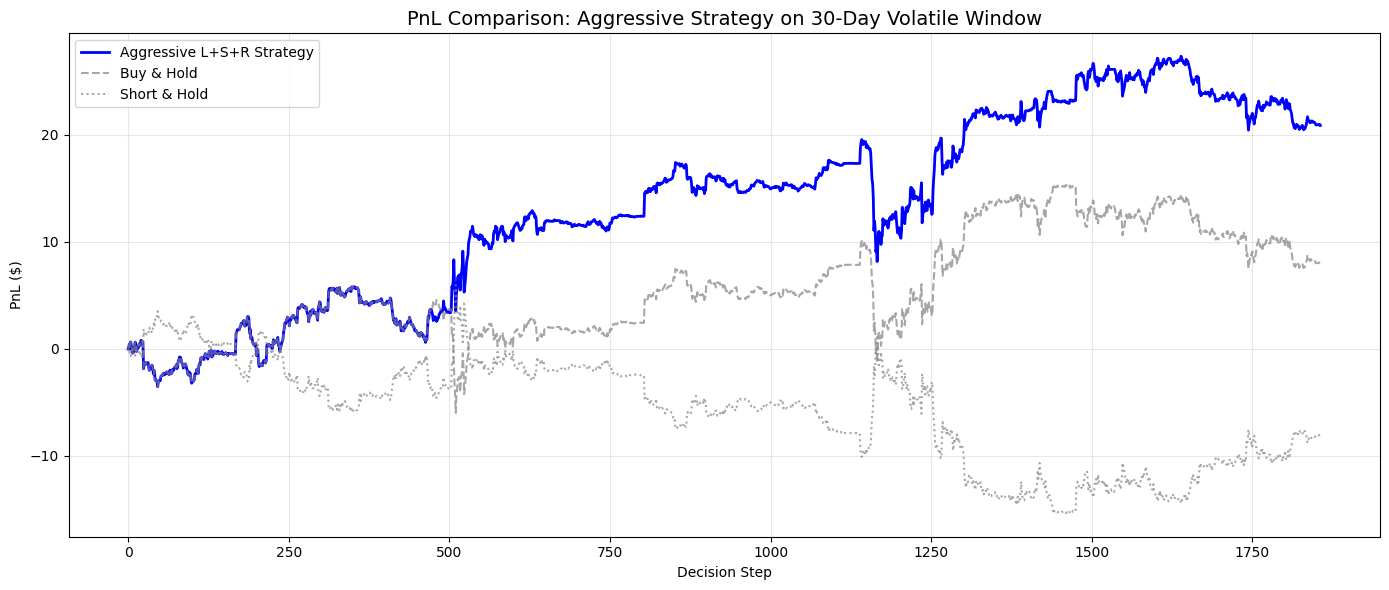

In [21]:
# --- Setup Comparisons ---
prices = df_test['close'].values
P_start = prices[SEQ_LEN]
bh_full = prices - P_start
sh_full = P_start - prices

# Align timestamps
anchor_times = [
    w * STEP + SEQ_LEN
    for w in range(Y_pred_test.shape[0])
    if w * STEP + SEQ_LEN < len(prices)
]
bh_curve = bh_full[anchor_times]
sh_curve = sh_full[anchor_times]

# --- End of Day Flattening ---
day_groups = df_test.groupby(df_test['date'].dt.date).apply(lambda g: g.index.to_numpy())
eod_flat_indices = set()
for _, idx_arr in day_groups.items():
    if len(idx_arr) >= 5: eod_flat_indices.update(idx_arr[-5:])
    else: eod_flat_indices.update(idx_arr)

# --- Strategy Parameters ---
T_ENTER = 0.0005
T_EXIT  = 0.0002
T_FLIP  = 0.0008

def current_equity(p0, position, entry_price, pnl_realized):
    if position == 0 or entry_price is None:
        return pnl_realized
    return pnl_realized + position * (p0 - entry_price)

position = 0
entry_price = None
pnl_realized = 0.0
equity_curve_aggr = []
num_trades = 0
num_flips = 0

# --- Trading Loop ---
for w in range(Y_pred_test.shape[0]):
    t0 = w * STEP + SEQ_LEN
    if t0 >= len(prices):
        break

    P0 = prices[t0]

    # Signal weights (short-term focus)
    P1  = Y_pred_test[w, 1]
    P10 = Y_pred_test[w, 10]
    P30 = Y_pred_test[w, 30]

    r1  = (P1 - P0) / P0
    r10 = (P10 - P0) / P0
    r30 = (P30 - P0) / P0

    signal = 0.6 * r1 + 0.3 * r10 + 0.1 * r30

    # Signal to Direction
    if signal > T_ENTER:
        desired = 1
    elif signal < -T_ENTER:
        desired = -1
    else:
        desired = 0

    if t0 in eod_flat_indices:
        desired = 0

    # State Machine
    if position == 0:
        if desired != 0:
            position = desired
            entry_price = P0
            num_trades += 1

    elif position == 1:
        if signal < -T_FLIP:
            pnl_realized += (P0 - entry_price)
            num_flips += 1; num_trades += 2
            position = -1
            entry_price = P0
        elif abs(signal) < T_EXIT or desired == 0:
            pnl_realized += (P0 - entry_price)
            position = 0
            entry_price = None
            num_trades += 1

    elif position == -1:
        if signal > T_FLIP:
            pnl_realized += (entry_price - P0)
            num_flips += 1; num_trades += 2
            position = 1
            entry_price = P0
        elif abs(signal) < T_EXIT or desired == 0:
            pnl_realized += (entry_price - P0)
            position = 0
            entry_price = None
            num_trades += 1

    eq = current_equity(P0, position, entry_price, pnl_realized)
    equity_curve_aggr.append(eq)

print("Aggressive Strategy Final PnL:", pnl_realized)
print("Total Trades:", num_trades, "Flips:", num_flips)

# --- Visualization ---
steps = np.arange(len(equity_curve_aggr))

plt.figure(figsize=(14,6))
plt.plot(steps, equity_curve_aggr, label="Aggressive L+S+R Strategy", linewidth=2, color='blue')
plt.plot(steps, bh_curve[:len(steps)], label="Buy & Hold", linestyle="--", color='gray', alpha=0.7)
plt.plot(steps, sh_curve[:len(steps)], label="Short & Hold", linestyle=":", color='gray', alpha=0.7)
plt.title("PnL Comparison: Aggressive Strategy on 30-Day Volatile Window", fontsize=14)
plt.xlabel("Decision Step")
plt.ylabel("PnL ($)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()